# Supplier Performance Analysis

## Project Overview

This notebook evaluates supplier performance using procurement and delivery data from a manufacturing-style supply chain.

The analysis focuses on:

- Supplier spend
- Lead times
- Delivery reliability
- Procurement KPIs

The objective is to identify high-performing and underperforming suppliers and support data-driven procurement decisions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

suppliers = pd.read_csv("suppliers.csv")
purchase_orders = pd.read_csv("purchase_orders.csv")

print("Suppliers:", suppliers.shape)
print("Purchase Orders:", purchase_orders.shape)

suppliers.head()

Suppliers: (50, 8)
Purchase Orders: (5000, 10)


,Supplier_ID,Supplier_Name,Country,Category,Lead_Time_Days,On_Time_Delivery_Percent,Defect_Rate_Percent,Annual_Spend
0,S001,Supplier 1,China,Raw Materials,54,70.2,3.96,473728.38
1,S002,Supplier 2,Germany,Chemicals,41,71.4,6.49,629769.94
2,S003,Supplier 3,UK,Raw Materials,17,91.5,3.70,465841.50
3,S004,Supplier 4,India,Chemicals,39,71.1,5.57,157596.80
4,S005,Supplier 5,Pakistan,Electronics,49,93.4,3.23,403440.30


## Procurement KPI Overview

This section evaluates overall procurement performance by examining total spend, supplier lead times, and delivery reliability.

These KPIs provide a high-level assessment of supply chain efficiency and supplier performance.

In [4]:
total_spend = purchase_orders["PO_Value"].sum()

avg_lead_time = suppliers["Lead_Time_Days"].mean()

delay_rate = (
    (purchase_orders["Status"] == "Delayed").mean()
) * 100

num_suppliers = suppliers["Supplier_ID"].nunique()

print(f"Total Procurement Spend: £{total_spend:,.0f}")
print(f"Average Lead Time: {avg_lead_time:.1f} days")
print(f"Delayed Order Rate: {delay_rate:.1f}%")
print(f"Number of Suppliers: {num_suppliers}")

Total Procurement Spend: £37,242,443
Average Lead Time: 34.5 days
Delayed Order Rate: 18.6%
Number of Suppliers: 50


## Top Performing Suppliers

Suppliers are ranked based on on-time delivery performance.

Reliable suppliers contribute to reduced disruption, lower inventory risk, and improved service levels.

In [5]:
top_suppliers = suppliers.sort_values(
    "On_Time_Delivery_Percent",
    ascending=False
)

top_suppliers[
    [
        "Supplier_Name",
        "Country",
        "On_Time_Delivery_Percent",
        "Lead_Time_Days",
        "Annual_Spend"
    ]
].head(10)

,Supplier_Name,Country,On_Time_Delivery_Percent,Lead_Time_Days,Annual_Spend
10,Supplier 11,India,95.8,12,46809.94
13,Supplier 14,India,95.4,54,366699.11
34,Supplier 35,China,95.2,43,419365.34
16,Supplier 17,India,95.1,37,732918.98
12,Supplier 13,Germany,95.0,48,330811.14
11,Supplier 12,Germany,94.4,24,608085.95
41,Supplier 42,Pakistan,93.6,55,553211.08
4,Supplier 5,Pakistan,93.4,49,403440.30
47,Supplier 48,UAE,93.2,16,638639.87
15,Supplier 16,India,93.1,21,267030.17


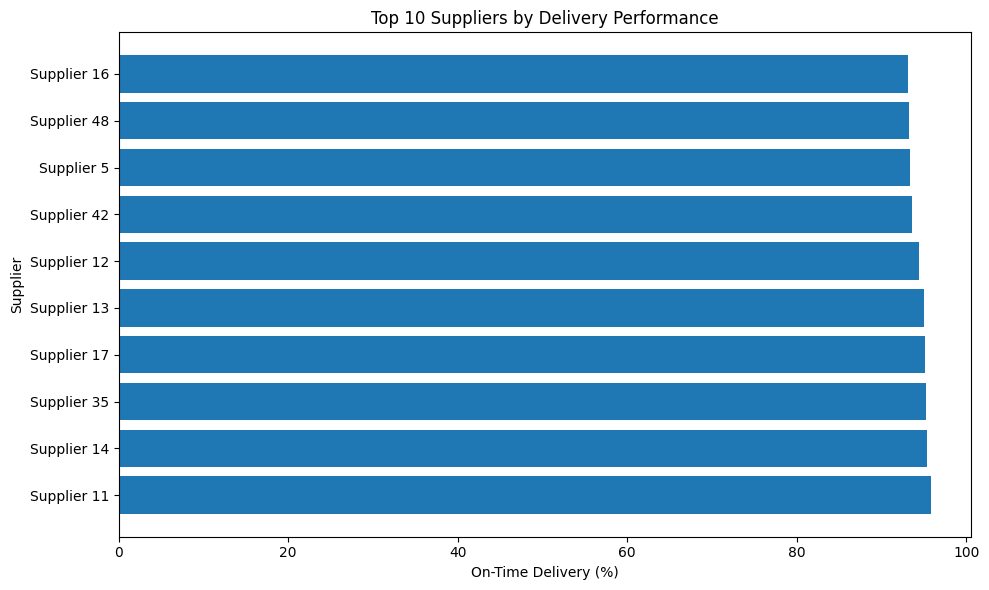

In [6]:
top10 = suppliers.sort_values(
    "On_Time_Delivery_Percent",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Supplier_Name"],
    top10["On_Time_Delivery_Percent"]
)

plt.xlabel("On-Time Delivery (%)")
plt.ylabel("Supplier")

plt.title("Top 10 Suppliers by Delivery Performance")

plt.tight_layout()

plt.show()

## Key Findings

The supplier analysis identified several suppliers achieving on-time delivery rates above 95%, demonstrating strong delivery reliability and operational performance.

Reliable suppliers reduce the risk of production delays and inventory shortages, making them valuable strategic partners.

Further investigation should focus on suppliers with lower delivery performance to identify opportunities for performance improvement, supplier development, or alternative sourcing strategies.

In [7]:
supplier_scorecard = suppliers.copy()

supplier_scorecard["Performance_Score"] = (
    supplier_scorecard["On_Time_Delivery_Percent"] * 0.7
    - supplier_scorecard["Defect_Rate_Percent"] * 5
)

supplier_scorecard = supplier_scorecard.sort_values(
    "Performance_Score",
    ascending=False
)

supplier_scorecard[
    [
        "Supplier_Name",
        "Country",
        "On_Time_Delivery_Percent",
        "Defect_Rate_Percent",
        "Lead_Time_Days",
        "Performance_Score"
    ]
].head(10)

,Supplier_Name,Country,On_Time_Delivery_Percent,Defect_Rate_Percent,Lead_Time_Days,Performance_Score
47,Supplier 48,UAE,93.2,0.35,16,63.49
11,Supplier 12,Germany,94.4,0.68,24,62.68
10,Supplier 11,India,95.8,1.30,12,60.56
9,Supplier 10,India,87.9,0.26,28,60.23
18,Supplier 19,Turkey,87.1,0.37,12,59.12
48,Supplier 49,Germany,93.1,1.24,58,58.97
36,Supplier 37,Germany,81.2,0.36,53,55.04
7,Supplier 8,Turkey,87.3,1.47,18,53.76
12,Supplier 13,Germany,95.0,2.56,48,53.70
24,Supplier 25,Germany,85.8,1.56,59,52.26


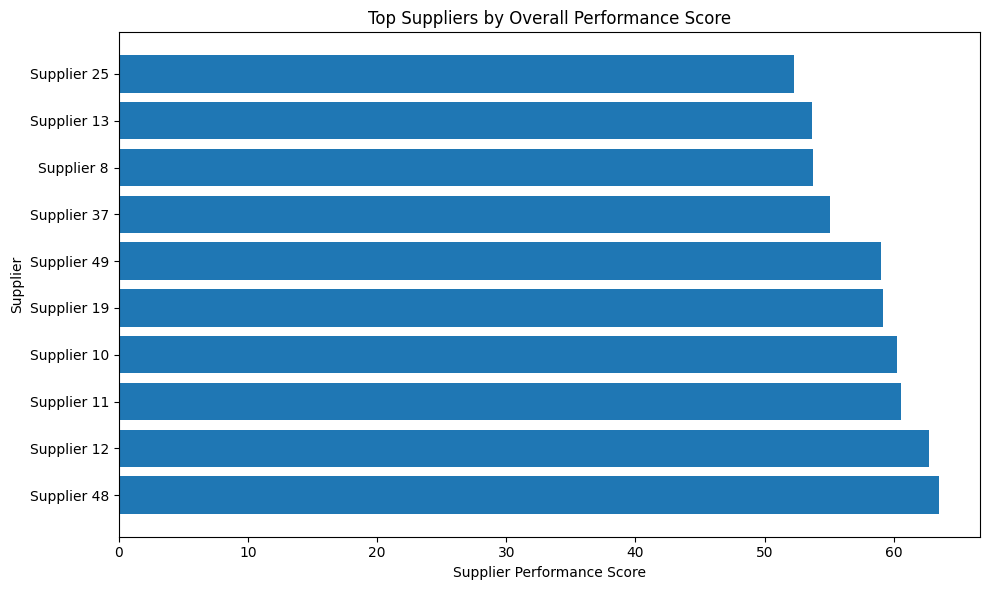

In [8]:
top_scorecard = supplier_scorecard.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_scorecard["Supplier_Name"],
    top_scorecard["Performance_Score"]
)

plt.xlabel("Supplier Performance Score")
plt.ylabel("Supplier")

plt.title("Top Suppliers by Overall Performance Score")

plt.tight_layout()

plt.show()

# Inventory Analytics

## Business Objective

Inventory is one of the largest sources of cost and operational risk in a supply chain.

This analysis evaluates inventory value, stockout risk, and replenishment requirements to support inventory planning decisions.

In [10]:
inventory = pd.read_csv("inventory.csv")

print("Inventory Records:", inventory.shape)

inventory.head()

Inventory Records: (500, 8)


,Product_ID,Product_Name,Category,Current_Stock,Safety_Stock,Reorder_Point,Unit_Cost,Inventory_Value
0,P0001,Product 1,Raw Material,120,77,752,38.69,4642.80
1,P0002,Product 2,Finished Goods,2038,400,227,24.27,49462.26
2,P0003,Product 3,Finished Goods,103,675,394,18.09,1863.27
3,P0004,Product 4,Raw Material,3796,147,1131,16.68,63317.28
4,P0005,Product 5,Spare Parts,4476,652,1083,90.59,405480.84


## Stockout Risk Analysis

Products with inventory levels below their reorder points are considered at risk of stockout and may require replenishment action.

Identifying these products helps reduce operational disruption and maintain service levels.

In [11]:
stockout_risk = inventory[
    inventory["Current_Stock"] < inventory["Reorder_Point"]
]

print("Products at Stockout Risk:")
print(len(stockout_risk))

stockout_risk[
    [
        "Product_ID",
        "Product_Name",
        "Current_Stock",
        "Reorder_Point"
    ]
].head(10)

Products at Stockout Risk:
62


,Product_ID,Product_Name,Current_Stock,Reorder_Point
0,P0001,Product 1,120,752
2,P0003,Product 3,103,394
8,P0009,Product 9,94,571
9,P0010,Product 10,526,1129
13,P0014,Product 14,575,1028
15,P0016,Product 16,219,555
16,P0017,Product 17,49,223
20,P0021,Product 21,199,926
25,P0026,Product 26,111,1004
45,P0046,Product 46,420,429


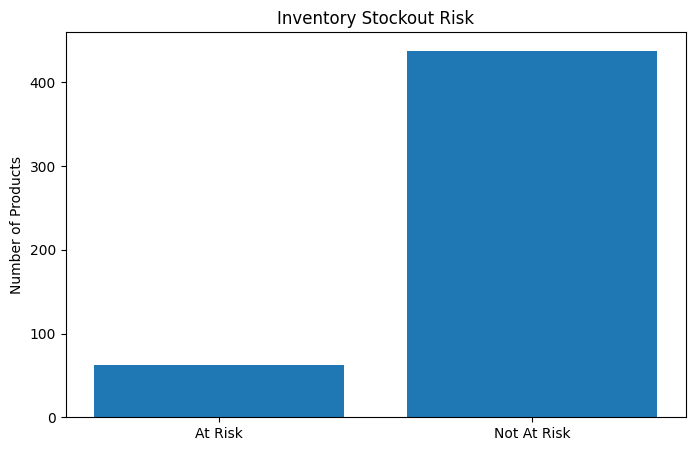

In [12]:
plt.figure(figsize=(8,5))

risk_counts = [
    len(stockout_risk),
    len(inventory) - len(stockout_risk)
]

plt.bar(
    ["At Risk", "Not At Risk"],
    risk_counts
)

plt.title("Inventory Stockout Risk")

plt.ylabel("Number of Products")

plt.show()

In [13]:
top_inventory = inventory.sort_values(
    "Inventory_Value",
    ascending=False
)

top_inventory[
    [
        "Product_Name",
        "Current_Stock",
        "Unit_Cost",
        "Inventory_Value"
    ]
].head(10)

,Product_Name,Current_Stock,Unit_Cost,Inventory_Value
116,Product 117,3428,355.54,1218791.12
247,Product 248,4355,192.06,836421.30
151,Product 152,4992,149.09,744257.28
42,Product 43,4138,150.88,624341.44
37,Product 38,3149,193.92,610654.08
209,Product 210,4995,103.76,518281.20
166,Product 167,4893,97.28,475991.04
133,Product 134,2818,154.06,434141.08
268,Product 269,3979,103.19,410593.01
50,Product 51,4183,97.67,408553.61


## ABC Inventory Analysis

ABC analysis classifies products based on their contribution to total inventory value.

This helps organisations focus inventory management efforts on the most financially significant products.

In [14]:
abc = inventory.copy()

abc = abc.sort_values(
    "Inventory_Value",
    ascending=False
)

abc["Cumulative_Value"] = abc["Inventory_Value"].cumsum()

abc["Cumulative_Percent"] = (
    abc["Cumulative_Value"]
    / abc["Inventory_Value"].sum()
)

abc["ABC_Class"] = np.where(
    abc["Cumulative_Percent"] <= 0.80,
    "A",
    np.where(
        abc["Cumulative_Percent"] <= 0.95,
        "B",
        "C"
    )
)

abc[[
    "Product_Name",
    "Inventory_Value",
    "Cumulative_Percent",
    "ABC_Class"
]].head(20)

,Product_Name,Inventory_Value,Cumulative_Percent,ABC_Class
116,Product 117,1218791.12,0.027686,A
247,Product 248,836421.30,0.046686,A
151,Product 152,744257.28,0.063592,A
42,Product 43,624341.44,0.077775,A
37,Product 38,610654.08,0.091646,A
209,Product 210,518281.20,0.103420,A
166,Product 167,475991.04,0.114232,A
133,Product 134,434141.08,0.124094,A
268,Product 269,410593.01,0.133421,A
50,Product 51,408553.61,0.142702,A


In [15]:
abc_summary = abc.groupby(
    "ABC_Class"
).agg(
    Products=("Product_ID", "count"),
    Total_Value=("Inventory_Value", "sum")
)

abc_summary

,Products,Total_Value
ABC_Class,,
A,210,35169249.97
B,135,6640099.74
C,155,2212731.88


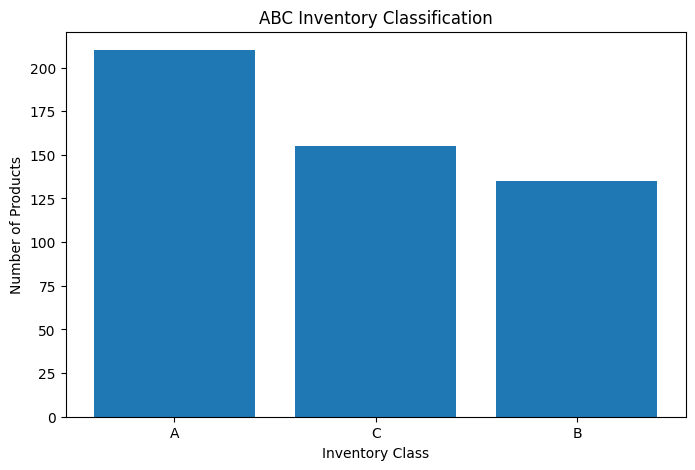

In [16]:
abc_counts = abc["ABC_Class"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    abc_counts.index,
    abc_counts.values
)

plt.title("ABC Inventory Classification")

plt.xlabel("Inventory Class")

plt.ylabel("Number of Products")

plt.show()

## ABC Analysis Findings

The ABC analysis shows that a relatively small number of products account for the majority of inventory value.

Class A products should receive the highest level of management attention due to their financial significance and impact on working capital.

Class B products require regular monitoring, while Class C products can generally be managed using simpler replenishment policies.

## Management Interpretation

ABC analysis demonstrates that inventory value is highly concentrated among a relatively small subset of products.

Class A products account for approximately 80% of total inventory value and should therefore receive the highest level of management attention. These products should be monitored closely, with frequent inventory reviews and tighter replenishment controls.

Class B products represent moderate financial importance and require regular monitoring.

Class C products contribute only a small proportion of total inventory value and can typically be managed using simpler replenishment policies with less frequent review cycles.

This prioritisation approach helps organisations improve working capital efficiency while reducing stockout and inventory holding risks.

# Demand Forecasting

## Business Objective

Demand forecasting helps organisations anticipate future customer demand and make informed inventory and procurement decisions.

Accurate forecasts support inventory optimisation, reduce stockouts, and improve service levels.

In [18]:
demand = pd.read_csv("demand_history.csv")

print(demand.shape)

demand.head()

(12000, 3)


,Date,Product_ID,Demand
0,2024-01-01,P0001,247
1,2024-02-01,P0001,276
2,2024-03-01,P0001,284
3,2024-04-01,P0001,296
4,2024-05-01,P0001,260


In [19]:
demand["Date"] = pd.to_datetime(demand["Date"])

monthly_demand = (
    demand.groupby("Date")["Demand"]
    .sum()
    .reset_index()
)

monthly_demand.head()

,Date,Demand
0,2024-01-01,398236
1,2024-02-01,426193
2,2024-03-01,448979
3,2024-04-01,462733
4,2024-05-01,451822


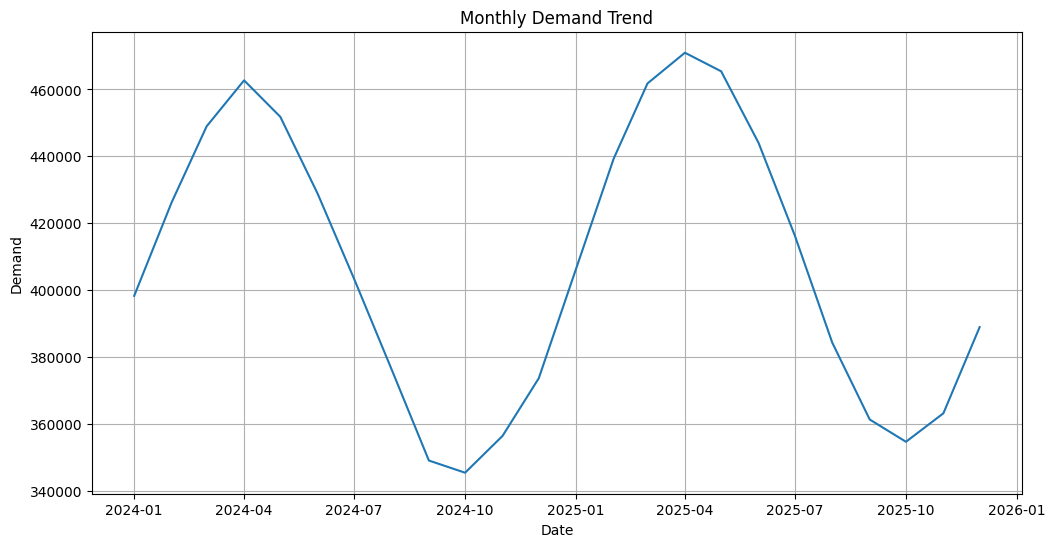

In [20]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_demand["Date"],
    monthly_demand["Demand"]
)

plt.title("Monthly Demand Trend")

plt.xlabel("Date")
plt.ylabel("Demand")

plt.grid(True)

plt.show()

## Demand Forecasting Model

A simple moving average forecasting approach was applied to estimate future demand based on historical demand patterns.

Forecasting supports inventory planning, procurement scheduling, and resource allocation decisions.

In [21]:
monthly_demand["Forecast"] = (
    monthly_demand["Demand"]
    .rolling(window=3)
    .mean()
)

monthly_demand.tail()

,Date,Demand,Forecast
19,2025-08-01,384235,414839.333333
20,2025-09-01,361253,387258.666667
21,2025-10-01,354586,366691.333333
22,2025-11-01,363111,359650.000000
23,2025-12-01,388892,368863.000000


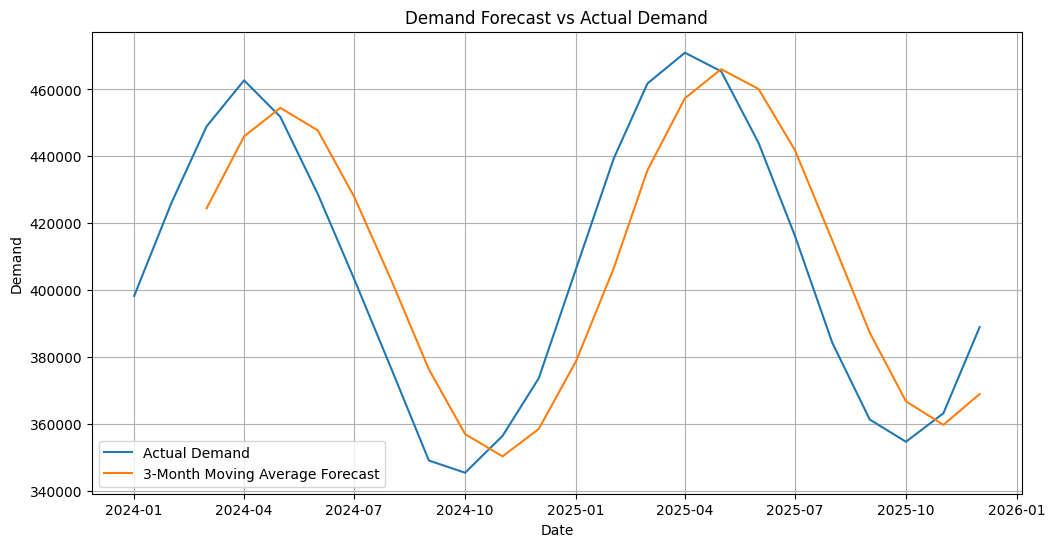

In [22]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_demand["Date"],
    monthly_demand["Demand"],
    label="Actual Demand"
)

plt.plot(
    monthly_demand["Date"],
    monthly_demand["Forecast"],
    label="3-Month Moving Average Forecast"
)

plt.title("Demand Forecast vs Actual Demand")

plt.xlabel("Date")
plt.ylabel("Demand")

plt.legend()

plt.grid(True)

plt.show()

## Forecasting Findings

The moving average forecast successfully captures the overall trend and seasonal behaviour of demand.

While the model smooths short-term fluctuations, it provides a useful baseline for inventory planning and procurement scheduling.

Future improvements could include more advanced forecasting techniques such as Exponential Smoothing, ARIMA, or machine learning-based forecasting models.